In [1]:
# Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataframe
df = pd.read_csv('new_my_features.csv')
df.head()

,query_id,query_contents,query_length,stopword_count,nonstopword_count,stopword_density,nonstopword_density,what,where,when,...,cls_761,cls_762,cls_763,cls_764,cls_765,cls_766,cls_767,best_model,Best Alpha,MRR
0,1048585,what is paula deen's brother,6,2,4,0.333333,0.666667,1,0,0,...,-0.316542,0.164232,-0.089220,-0.071347,-0.031938,0.285646,0.290846,simlm,0.51,0.333333
1,2,Androgen receptor define,3,0,3,0.000000,1.000000,0,0,0,...,-0.050720,0.171317,-0.123599,-0.302324,0.148471,0.649183,-0.100653,splade,0.03,1.000000
2,524332,treating tension headaches without medication,5,0,5,0.000000,1.000000,0,0,0,...,0.088614,0.271708,-0.158394,-0.384479,0.177981,0.435811,-0.153385,splade,1.00,0.023810
3,1048642,what is paranoid sc,4,2,2,0.500000,0.500000,1,0,0,...,-0.068101,0.137655,-0.179666,-0.398831,-0.017433,0.020971,-0.071258,splade,0.63,0.100000
4,524447,treatment of varicose veins in legs,6,2,4,0.333333,0.666667,0,0,0,...,-0.133143,0.376936,-0.210180,-0.285664,0.195498,0.727291,-0.124383,simlm,0.03,0.083333


In [3]:
# all ids in df are unique
print(df["query_id"].nunique())

6980


In [4]:
print(df.shape)
print(np.mean(df["MRR"]))

(6980, 784)
0.5102473878223496


In [5]:
buckets_train = []

for i in range(df.shape[0]):
    if df.iloc[i, 782] >= 0.9:
        buckets_train.append(9)
    elif df.iloc[i, 782] >= 0.8:
        buckets_train.append(8)
    elif df.iloc[i, 782] >= 0.7:
        buckets_train.append(7)
    elif df.iloc[i, 782] >= 0.6:
        buckets_train.append(6)
    elif df.iloc[i, 782] >= 0.5:
        buckets_train.append(5)
    elif df.iloc[i, 782] >= 0.4:
        buckets_train.append(4)
    elif df.iloc[i, 782] >= 0.3:
        buckets_train.append(3)
    elif df.iloc[i, 782] >= 0.2:
        buckets_train.append(2)
    elif df.iloc[i, 782] >= 0.1:
        buckets_train.append(1)
    else:
        buckets_train.append(0)

df["alpha_buckets"] = buckets_train

In [6]:
feature_cols = [col for col in df.columns if col.startswith('cls_')] + [
    'stopword_count', 'nonstopword_count',
    'stopword_density', 'nonstopword_density',
    'query_length', 'what', 'where', 'when'
]

target_cols = ['query_id', 'alpha_buckets']

# X and y dataframes
X = df[feature_cols]
y = df[target_cols]

X.head()

,cls_0,cls_1,cls_2,cls_3,cls_4,cls_5,cls_6,cls_7,cls_8,cls_9,...,cls_766,cls_767,stopword_count,nonstopword_count,stopword_density,nonstopword_density,query_length,what,where,when
0,-0.062403,0.027169,0.270110,0.207758,-0.060775,0.176636,-0.010139,-0.335960,0.075902,-0.534105,...,0.285646,0.290846,2,4,0.333333,0.666667,6,1,0,0
1,-0.093802,0.026285,0.276022,0.158549,0.240934,0.205888,0.180795,-0.169981,-0.014223,-0.287796,...,0.649183,-0.100653,0,3,0.000000,1.000000,3,0,0,0
2,-0.123280,-0.080808,0.291058,0.446603,-0.006283,-0.004077,0.116068,-0.064539,-0.030202,-0.194538,...,0.435811,-0.153385,0,5,0.000000,1.000000,5,0,0,0
3,-0.097564,0.200338,0.162613,0.269157,-0.548503,0.090923,0.157506,-0.074866,-0.481509,-0.719581,...,0.020971,-0.071258,2,2,0.500000,0.500000,4,1,0,0
4,0.013936,-0.089972,0.497938,0.602115,-0.045929,-0.195976,0.119508,0.158035,-0.314570,-0.288453,...,0.727291,-0.124383,2,4,0.333333,0.666667,6,0,0,0


In [8]:
print(y)

      query_id  alpha_buckets
0      1048585              5
1            2              0
2       524332              9
3      1048642              6
4       524447              0
...        ...            ...
6975    734979              1
6976    524166              1
6977    968921              3
6978    786375              3
6979   1048565              9

[6980 rows x 2 columns]


In [9]:
print(X.shape)

(6980, 776)


In [10]:
# buckets = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
bucket_labels = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
# y_bucketed = np.digitize(y, buckets)
# y_bucketed = y_bucketed - 1

In [11]:
# print(y_bucketed)

In [12]:
# print(len(y_bucketed))

In [13]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
# Training and testing sets (CHANGE TEST SIZE?)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [15]:
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation='relu',
    solver='adam',
    alpha=0.01,
    batch_size='auto',
    learning_rate='adaptive',
    max_iter=300,
    random_state=42,
    verbose=True
)

In [16]:
print(y_train)

      query_id  alpha_buckets
6610    249792              0
6565    510152              3
4003    930293              8
1010   1098057              7
4617    436586              6
...        ...            ...
3772    131768              2
5191    988294              9
5226    995029              5
5390    993748              8
860     398335              2

[5584 rows x 2 columns]


In [17]:
# Train/fit model
mlp.fit(X_train, y_train['alpha_buckets'])

# Predictions
y_pred = mlp.predict(X_test)

Iteration 1, loss = 2.41505395
Iteration 2, loss = 2.04968285
Iteration 3, loss = 1.87154464
Iteration 4, loss = 1.70121647
Iteration 5, loss = 1.51639740
Iteration 6, loss = 1.33260874
Iteration 7, loss = 1.16129902
Iteration 8, loss = 0.97920746
Iteration 9, loss = 0.81241098
Iteration 10, loss = 0.65865376
Iteration 11, loss = 0.52546706
Iteration 12, loss = 0.42768562
Iteration 13, loss = 0.33028935
Iteration 14, loss = 0.25121942
Iteration 15, loss = 0.19773485
Iteration 16, loss = 0.15200474
Iteration 17, loss = 0.12456237
Iteration 18, loss = 0.10301384
Iteration 19, loss = 0.08657416
Iteration 20, loss = 0.07452546
Iteration 21, loss = 0.06736048
Iteration 22, loss = 0.06315112
Iteration 23, loss = 0.05636442
Iteration 24, loss = 0.05248251
Iteration 25, loss = 0.05210266
Iteration 26, loss = 0.04967224
Iteration 27, loss = 0.04655036
Iteration 28, loss = 0.04285664
Iteration 29, loss = 0.04094982
Iteration 30, loss = 0.04001341
Iteration 31, loss = 0.03798957
Iteration 32, los

In [18]:
print(y_pred)

[0 2 8 ... 4 2 3]


Accuracy: 0.1239

Classification Report:
              precision    recall  f1-score   support

           0       0.19      0.19      0.19       300
           1       0.11      0.12      0.11       120
           2       0.08      0.07      0.07       109
           3       0.11      0.09      0.10        96
           4       0.07      0.07      0.07       108
           5       0.08      0.07      0.07       100
           6       0.07      0.06      0.07        99
           7       0.10      0.09      0.09       105
           8       0.07      0.06      0.07       127
           9       0.16      0.20      0.18       232

    accuracy                           0.12      1396
   macro avg       0.10      0.10      0.10      1396
weighted avg       0.12      0.12      0.12      1396


Confusion Matrix:
[[57 34 28 24 24 26 17 14 23 53]
 [25 14 11  4 11  6  8  3 11 27]
 [21  9  8  3 11  8  3  9 12 25]
 [25 11  5  9  9  2  3  4 12 16]
 [19  6  9  8  8  5 10 15  9 19]
 [21  9  8  3  5

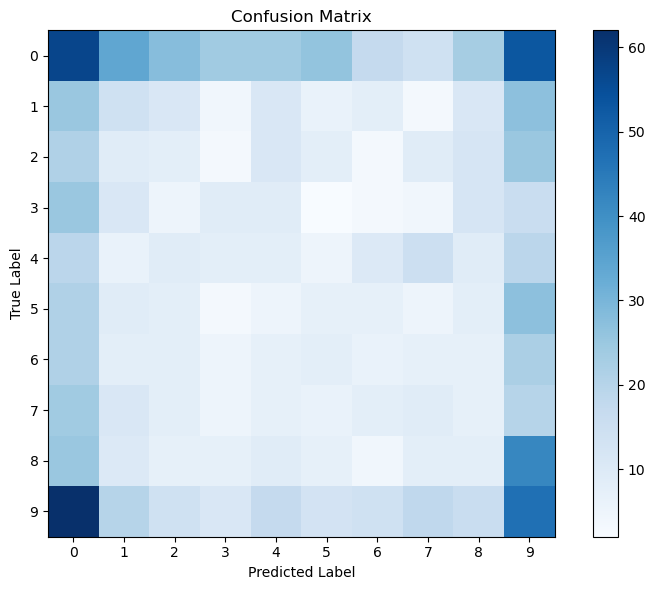

In [19]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Evaluate performance
accuracy = accuracy_score(y_test['alpha_buckets'], y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test['alpha_buckets'], y_pred))

# Display confusion matrix
conf_matrix = confusion_matrix(y_test['alpha_buckets'], y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Visualize the confusion matrix
plt.figure(figsize=(8,6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(10)
plt.xticks(tick_marks, bucket_labels)
plt.yticks(tick_marks, bucket_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Checking errors
mse = mean_squared_error(y_test['alpha_buckets'], y_pred)
rmse = mean_squared_error(y_test['alpha_buckets'], y_pred, squared=False)
mae = mean_absolute_error(y_test['alpha_buckets'], y_pred)
r2 = r2_score(y_test['alpha_buckets'], y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")


MSE: 22.6533
RMSE: 4.7595
MAE: 3.8152
R²: -1.0316


In [21]:
y_pred_train = mlp.predict(X_train)
y_pred_test = mlp.predict(X_test)

mse_train = mean_squared_error(y_train['alpha_buckets'], y_pred_train)
mse_test = mean_squared_error(y_test['alpha_buckets'], y_pred_test)
r2_train = r2_score(y_train['alpha_buckets'], y_pred_train)
r2_test = r2_score(y_test['alpha_buckets'], y_pred_test)

print(f"Train MSE: {mse_train:.4f}, Test MSE: {mse_test:.4f}")
print(f"Train R2: {r2_train:.4f}, Test R2: {r2_test:.4f}")

Train MSE: 0.0000, Test MSE: 22.6533
Train R2: 1.0000, Test R2: -1.0316


In [22]:
feature_cols = [col for col in df.columns if col.startswith('cls_')] + [
    'stopword_count', 'nonstopword_count',
    'stopword_density', 'nonstopword_density',
    'query_length', 'what', 'where', 'when'
]
new_X = df[feature_cols]

y_new_pred = mlp.predict(new_X)
print(y_new_pred)

df['predicted_value'] = y_new_pred 

df.to_csv("predicted_output.csv", index=False)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(


[1 1 4 ... 1 3 1]


In [23]:
print(y_pred)

[0 2 8 ... 4 2 3]


In [24]:
alpha_map = {
    '0': 0,
    '1': 0.1,
    '2': 0.2,
    '3': 0.3,
    '4': 0.4,
    '5': 0.5,
    '6': 0.6,
    '7': 0.7,
    '8': 0.8,
    '9': 0.9,
}

y_pred_list = [str(x) for x in y_pred.tolist()]

for i in range(len(y_pred_list)):
    y_pred_list[i] = alpha_map[y_pred_list[i]]

print(y_pred_list)

[0, 0.2, 0.8, 0.1, 0.9, 0.9, 0.9, 0.3, 0, 0.8, 0.1, 0.9, 0.9, 0.3, 0.9, 0.5, 0, 0, 0, 0.5, 0.4, 0.9, 0, 0.1, 0, 0.6, 0.2, 0, 0.2, 0.7, 0, 0.3, 0.9, 0.6, 0.7, 0.9, 0.1, 0.5, 0.6, 0.3, 0.9, 0, 0.1, 0.4, 0.9, 0.5, 0, 0.7, 0.1, 0.8, 0, 0.9, 0.9, 0.2, 0.9, 0.7, 0.7, 0.9, 0.9, 0.9, 0.6, 0.5, 0.8, 0, 0, 0.3, 0, 0.2, 0.8, 0.8, 0.1, 0.9, 0.4, 0.4, 0.9, 0.1, 0.7, 0.2, 0, 0.1, 0, 0.1, 0.1, 0.1, 0.4, 0.9, 0.7, 0.9, 0.2, 0.1, 0.8, 0.8, 0.6, 0.9, 0.9, 0.9, 0.9, 0, 0, 0.4, 0.7, 0.9, 0.7, 0.8, 0.1, 0, 0, 0.3, 0.2, 0, 0.3, 0, 0.9, 0, 0.8, 0.6, 0.5, 0.9, 0.5, 0, 0, 0.3, 0.6, 0.8, 0.9, 0, 0.5, 0, 0.7, 0.5, 0.3, 0.9, 0.8, 0.7, 0.9, 0, 0, 0.8, 0.1, 0.7, 0.7, 0.1, 0.9, 0.7, 0, 0.1, 0, 0.7, 0.8, 0.5, 0.3, 0, 0.4, 0.5, 0.1, 0, 0.7, 0.5, 0.9, 0.4, 0.7, 0.9, 0, 0.6, 0.1, 0.9, 0.2, 0, 0, 0, 0.9, 0.9, 0.9, 0.1, 0.9, 0.9, 0, 0.9, 0.9, 0.8, 0, 0.1, 0, 0.8, 0, 0.2, 0.5, 0.2, 0.4, 0.9, 0.9, 0.9, 0.2, 0.1, 0.6, 0.9, 0, 0.7, 0.8, 0, 0.3, 0.9, 0.9, 0.9, 0.9, 0.6, 0, 0.6, 0.2, 0.8, 0, 0.7, 0.3, 0.4, 0, 0.5, 0, 0.8, 0.2, 

In [25]:
qrels_df = pd.read_csv("qrels.dev.tsv", sep="\t", names=['Query ID', '0', 'Document ID', "Relevance"])
qrels_df = qrels_df.drop(columns=['0'])
qrels_df.head()

,Query ID,Document ID,Relevance
0,1102432,2026790,1
1,1102431,7066866,1
2,1102431,7066867,1
3,1090282,7066900,1
4,39449,7066905,1


In [26]:
print(qrels_df.shape)

(59273, 3)


In [27]:
print(df["query_id"])
print(len(y_pred))

data = {'Query ID': y_test["query_id"],
        'Alpha Values': y_pred}

results_df = pd.DataFrame(data)
print(results_df)

0       1048585
1             2
2        524332
3       1048642
4        524447
         ...   
6975     734979
6976     524166
6977     968921
6978     786375
6979    1048565
Name: query_id, Length: 6980, dtype: int64
1396
      Query ID  Alpha Values
4119    148761             0
3477    638928             2
4322    267187             8
3349    632055             1
469    1064473             9
...        ...           ...
1897   1095495             0
1032   1083535             6
4480    167204             4
3866    661398             2
1880    570979             3

[1396 rows x 2 columns]


In [28]:
splade_df = pd.read_csv("splade-dev.trec", sep="\t", names=['Query ID', 'Q0', 'Document ID', 'Rank', 'Score', 'R0'])
splade_df = splade_df.drop(splade_df.columns[[1,5]], axis=1)

dense_df = pd.read_csv("splade_llama_rerank.tsv", sep="\t", names=['Query ID', 'Document ID', 'Score'])

In [29]:
print(splade_df[splade_df["Query ID"] == 148761])
print(splade_df)

         Query ID  Document ID  Rank  Score
4119000    148761      7495325     0  75753
4119001    148761      7495323     1  73955
4119002    148761      7030056     2  72652
4119003    148761      7495324     3  72361
4119004    148761      7495320     4  71304
...           ...          ...   ...    ...
4119995    148761      2918872   995  41228
4119996    148761      5128952   996  41226
4119997    148761      3931295   997  41225
4119998    148761       724566   998  41210
4119999    148761      4152580   999  41203

[1000 rows x 4 columns]
         Query ID  Document ID  Rank   Score
0         1048585      7187155     0  104472
1         1048585      7187160     1  100811
2         1048585      7187157     2   99206
3         1048585      7187158     3   98698
4         1048585      3100835     4   86255
...           ...          ...   ...     ...
6979995   1048565      4838288   995   66246
6979996   1048565      2133477   996   66245
6979997   1048565      5753707   997   662

In [30]:
def best_weights_fixed(dense_df, sparse_df, query_id, alpha):
    # Initialize best MRR value
    best_mrr = 0

    # Filter by query ID
    filtered_dense_df = dense_df[dense_df["Query ID"] == query_id].copy()
    filtered_sparse_df = sparse_df[sparse_df["Query ID"] == query_id].copy()

    # Find weighted scores
    filtered_dense_df["Score"] *= (1 - alpha)
    filtered_sparse_df["Score"] *= alpha

    # Merge rankings
    merged = filtered_dense_df.merge(filtered_sparse_df, on="Document ID", how="outer", suffixes=("_dense", "_sparse")).fillna(0)
    merged["Final Score"] = merged["Score_dense"] + merged["Score_sparse"]

    # Rank documents
    ranked_results = merged.sort_values("Final Score", ascending=False)
    ranked_docs = ranked_results["Document ID"].tolist()[:10]

    # MRR
    relevant_docs = qrels_df[qrels_df["Query ID"] == query_id]["Document ID"]

    rank = len(ranked_docs) + 1
    for doc in relevant_docs:    
        if doc in ranked_docs:
            current_rank = ranked_docs.index(doc) + 1
            if current_rank < rank:
                rank = current_rank

    if rank > 10:
        mrr_score = 0
    else:
        mrr_score = 1 / rank

    return alpha, mrr_score


In [31]:
print(y_test["query_id"].to_list())

[148761, 638928, 267187, 632055, 1064473, 1066792, 512685, 744891, 1083743, 1086271, 247194, 510858, 199776, 1012431, 34039, 970605, 694561, 523062, 1094825, 1095557, 114633, 393954, 1096887, 1095335, 270642, 1083125, 998658, 884878, 65770, 56993, 70852, 571696, 1085862, 1097153, 1057270, 478295, 1014132, 583325, 1002197, 263670, 1092863, 662436, 1072479, 884533, 527625, 1090839, 266760, 156251, 1066971, 1056159, 544123, 37685, 76770, 990307, 1095749, 1022630, 161224, 432602, 975495, 1098570, 1092416, 1088475, 418552, 1083430, 1011618, 597870, 1091654, 1096087, 788484, 635125, 466202, 1087122, 1056950, 1084712, 1089043, 662282, 1088845, 244821, 714709, 605467, 1084516, 891498, 1002252, 855546, 881582, 679658, 458235, 1091529, 914406, 1038592, 783781, 1095807, 679167, 1100134, 1007696, 1002584, 944451, 1098222, 549731, 1084602, 1083909, 1054707, 809933, 81993, 1083267, 875787, 1006000, 375291, 21948, 1014242, 926700, 1087603, 684459, 1084273, 1062223, 392195, 1086305, 1096425, 705681, 8

In [32]:
alphas = []
mrrs = []

df_loaded = pd.read_csv("predicted_output.csv")
y_test_list = y_test["query_id"].to_list()

for idx, query in enumerate(y_test_list):
    # print(query)
    predicted_alpha = y_pred_list[idx]
    # print(predicted_alpha)
    # print(type(query))
    alpha, mrr = best_weights_fixed(dense_df, splade_df, query, predicted_alpha)
    alphas.append(alpha)
    mrrs.append(mrr)
    # if query % 100 == 0:
    #     print(query)

In [33]:
# MRR calculations
avg_mrr = sum(mrrs) / len(mrrs)
print(f"Avg MRRs: {avg_mrr}")

Avg MRRs: 0.38183443625778857
